J=1.2, mu=-2.5, n=0.206055, Delta0=0
J=1.2, mu=-2.29167, n=0.245117, Delta0=0
J=1.2, mu=-2.08333, n=0.304741, Delta0=0.00308747
J=1.2, mu=-1.875, n=0.356843, Delta0=0.026591
J=1.2, mu=-1.66667, n=0.433155, Delta0=0.107029
J=1.2, mu=-1.45833, n=0.528926, Delta0=0.166501
J=1.2, mu=-1.25, n=0.621194, Delta0=0.188395
J=1.2, mu=-1.04167, n=0.709392, Delta0=0.17808
J=1.2, mu=-0.833333, n=0.791928, Delta0=0.132499
J=1.2, mu=-0.625, n=0.861829, Delta0=0.049612
J=1.2, mu=-0.416667, n=0.908844, Delta0=0.0140829
J=1.2, mu=-0.208333, n=0.942383, Delta0=0
J=1.2, mu=0, n=0.97168, Delta0=0
Finished J=1.2; Delta0 range=(0, 0.1884) in 26.42 s
26.83055877685547 seconds


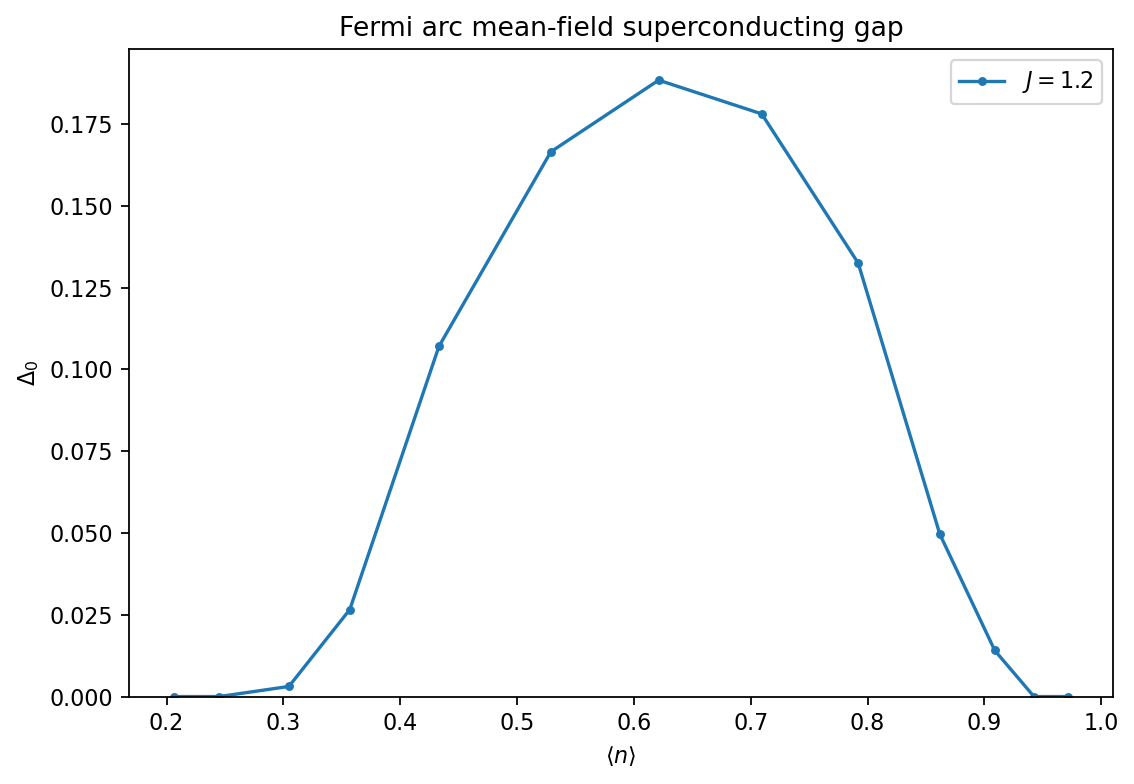

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    xi_k = -2(cos kx + cos ky)
           -4 t1 cos kx cos ky
           -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Block matrices for one Fermi-arc four-mode sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """Diagonalize all blocks and embed eigenvectors into the full 16D basis."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]
    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the Delta_k-channel pair operator ca."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def sector_density(kx, ky, mu, hop, U, Delta0, beta):
    """Average filling contribution of one four-mode sector."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    return 0.5 * np.sum(rho * np.diag(n_eigenbasis)).real


def triangular_kmesh(nk1d):
    """Triangular mesh 0 <= ky <= kx < pi, matching wormsc.tri_kmesh."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """Solve Delta0 = -J <g_k <c_-k down c_k up>> using scipy.root_scalar."""

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta):
    """Compute the triangular-mesh averaged filling for a given Delta0."""
    fillings = []
    for (kx, ky), weight in zip(k_points, k_weights):
        density_k = sector_density(kx, ky, mu, hop, U, Delta0, beta)
        fillings.append(weight * density_k)
    return float(np.sum(fillings) / np.sum(k_weights))


def gap_and_filling_for_mu(k_points, k_weights, J, mu, hop, U, beta):
    """Solve Delta0 at fixed mu and return filling, Delta0."""
    Delta0 = solve_gap_delta0(
        k_points,
        k_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )
    filling = filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta)
    return filling, Delta0


# -------------------------- user parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 2
J_values = [1.2]
temperature = 1e-04 * J_values[0]
beta = 1.0 / temperature

# Increase nk_gap and mu_points for smoother curves.
nk_gap = 32
mu_values = np.linspace(-2.5, 0, 13)

k_points, k_weights = triangular_kmesh(nk_gap)

plt.figure(figsize=(7.2, 5.0), dpi=160)

for J in J_values:
    fillings = []
    gaps = []
    curve_start = time.time()

    for mu in mu_values:
        filling, Delta0 = gap_and_filling_for_mu(
            k_points,
            k_weights,
            J=J,
            mu=mu,
            hop=hop,
            U=U,
            beta=beta,
        )
        fillings.append(filling)
        gaps.append(Delta0)
        print(f"J={J:.6g}, mu={mu:.6g}, n={filling:.6g}, Delta0={Delta0:.6g}")

    order = np.argsort(fillings)
    plt.plot(
        np.array(fillings)[order],
        np.array(gaps)[order],
        marker="o",
        markersize=3,
        label=rf"$J={J:.3g}$",
    )
    print(
        f"Finished J={J:.6g}; "
        f"Delta0 range=({np.min(gaps):.4g}, {np.max(gaps):.4g}) "
        f"in {time.time() - curve_start:.2f} s"
    )

plt.xlabel(r"$\langle n\rangle$")
plt.ylabel(r"$\Delta_0$")
plt.title(r"Fermi arc mean-field superconducting gap")
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()
# plt.savefig("fermi_arc_gap_vs_filling.png", bbox_inches="tight")
# plt.close()

print(time.time() - start_time, "seconds")


J=1.2, mu=-2.5, n=0.204154, Delta0=0
J=1.2, mu=-2.29167, n=0.247651, Delta0=0
J=1.2, mu=-2.08333, n=0.304002, Delta0=0
J=1.2, mu=-1.875, n=0.356664, Delta0=0.0227057
J=1.2, mu=-1.66667, n=0.433771, Delta0=0.106771
J=1.2, mu=-1.45833, n=0.528759, Delta0=0.166491
J=1.2, mu=-1.25, n=0.621187, Delta0=0.188395
J=1.2, mu=-1.04167, n=0.709392, Delta0=0.17808
J=1.2, mu=-0.833333, n=0.791939, Delta0=0.132493
J=1.2, mu=-0.625, n=0.862445, Delta0=0.0438307
J=1.2, mu=-0.416667, n=0.9086, Delta0=0
J=1.2, mu=-0.208333, n=0.942803, Delta0=0
J=1.2, mu=0, n=0.970973, Delta0=0
Finished J=1.2; Delta0 range=(0, 0.1884) in 31.33 s
31.43833088874817 seconds


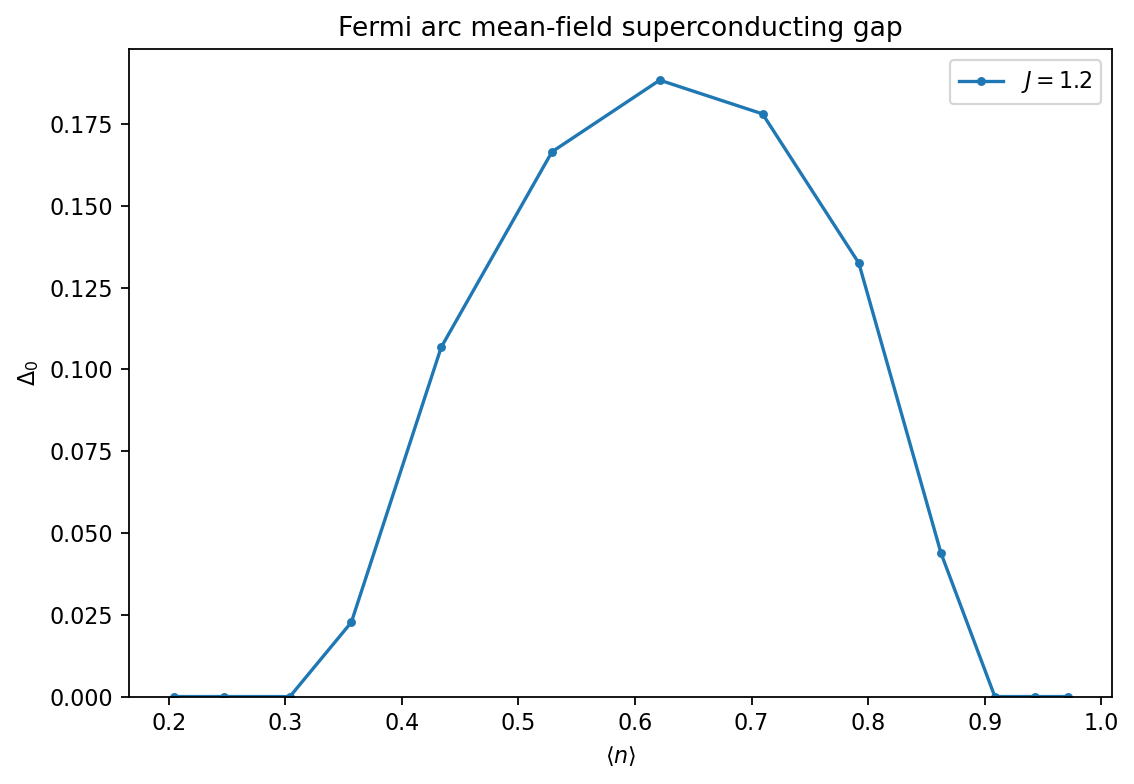

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    xi_k = -2(cos kx + cos ky)
           -4 t1 cos kx cos ky
           -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Block matrices for one Fermi-arc four-mode sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """Diagonalize all blocks and embed eigenvectors into the full 16D basis."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]
    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the Delta_k-channel pair operator ca."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def sector_density(kx, ky, mu, hop, U, Delta0, beta):
    """Average filling contribution of one four-mode sector."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    return 0.5 * np.sum(rho * np.diag(n_eigenbasis)).real


def triangular_kmesh(nk1d):
    """Triangular mesh 0 <= ky <= kx < pi, matching wormsc.tri_kmesh."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """Solve Delta0 = -J <g_k <c_-k down c_k up>> using scipy.root_scalar."""

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta):
    """Compute the triangular-mesh averaged filling for a given Delta0."""
    fillings = []
    for (kx, ky), weight in zip(k_points, k_weights):
        density_k = sector_density(kx, ky, mu, hop, U, Delta0, beta)
        fillings.append(weight * density_k)
    return float(np.sum(fillings) / np.sum(k_weights))


def gap_and_filling_for_mu(k_points, k_weights, J, mu, hop, U, beta):
    """Solve Delta0 at fixed mu and return filling, Delta0."""
    Delta0 = solve_gap_delta0(
        k_points,
        k_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )
    filling = filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta)
    return filling, Delta0


# -------------------------- user parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 2
J_values = [1.2]
# temperature = 1e-04 * J_values[0]
# beta = 1.0 / temperature
beta = 100

# Increase nk_gap and mu_points for smoother curves.
nk_gap = 32
mu_values = np.linspace(-2.5, 0, 13)

k_points, k_weights = triangular_kmesh(nk_gap)

plt.figure(figsize=(7.2, 5.0), dpi=160)

for J in J_values:
    fillings = []
    gaps = []
    curve_start = time.time()

    for mu in mu_values:
        filling, Delta0 = gap_and_filling_for_mu(
            k_points,
            k_weights,
            J=J,
            mu=mu,
            hop=hop,
            U=U,
            beta=beta,
        )
        fillings.append(filling)
        gaps.append(Delta0)
        print(f"J={J:.6g}, mu={mu:.6g}, n={filling:.6g}, Delta0={Delta0:.6g}")

    order = np.argsort(fillings)
    plt.plot(
        np.array(fillings)[order],
        np.array(gaps)[order],
        marker="o",
        markersize=3,
        label=rf"$J={J:.3g}$",
    )
    print(
        f"Finished J={J:.6g}; "
        f"Delta0 range=({np.min(gaps):.4g}, {np.max(gaps):.4g}) "
        f"in {time.time() - curve_start:.2f} s"
    )

plt.xlabel(r"$\langle n\rangle$")
plt.ylabel(r"$\Delta_0$")
plt.title(r"Fermi arc mean-field superconducting gap")
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()
# plt.savefig("fermi_arc_gap_vs_filling.png", bbox_inches="tight")
# plt.close()

print(time.time() - start_time, "seconds")


J=1.2, mu=-2.5, n=0.204154, Delta0=0
J=1.2, mu=-2.29167, n=0.247651, Delta0=0
J=1.2, mu=-2.08333, n=0.304002, Delta0=0
J=1.2, mu=-1.875, n=0.356683, Delta0=0.0231235
J=1.2, mu=-1.66667, n=0.435232, Delta0=0.112276
J=1.2, mu=-1.45833, n=0.53665, Delta0=0.183497
J=1.2, mu=-1.25, n=0.639415, Delta0=0.217086
J=1.2, mu=-1.04167, n=0.739711, Delta0=0.221153
J=1.2, mu=-0.833333, n=0.834576, Delta0=0.203559
J=1.2, mu=-0.625, n=0.92181, Delta0=0.171961
J=1.2, mu=-0.416667, n=1.0006, Delta0=0.134285
J=1.2, mu=-0.208333, n=1.07164, Delta0=0.0975971
J=1.2, mu=0, n=1.13562, Delta0=0.066343
Finished J=1.2; Delta0 range=(0, 0.2212) in 26.52 s
26.737489700317383 seconds


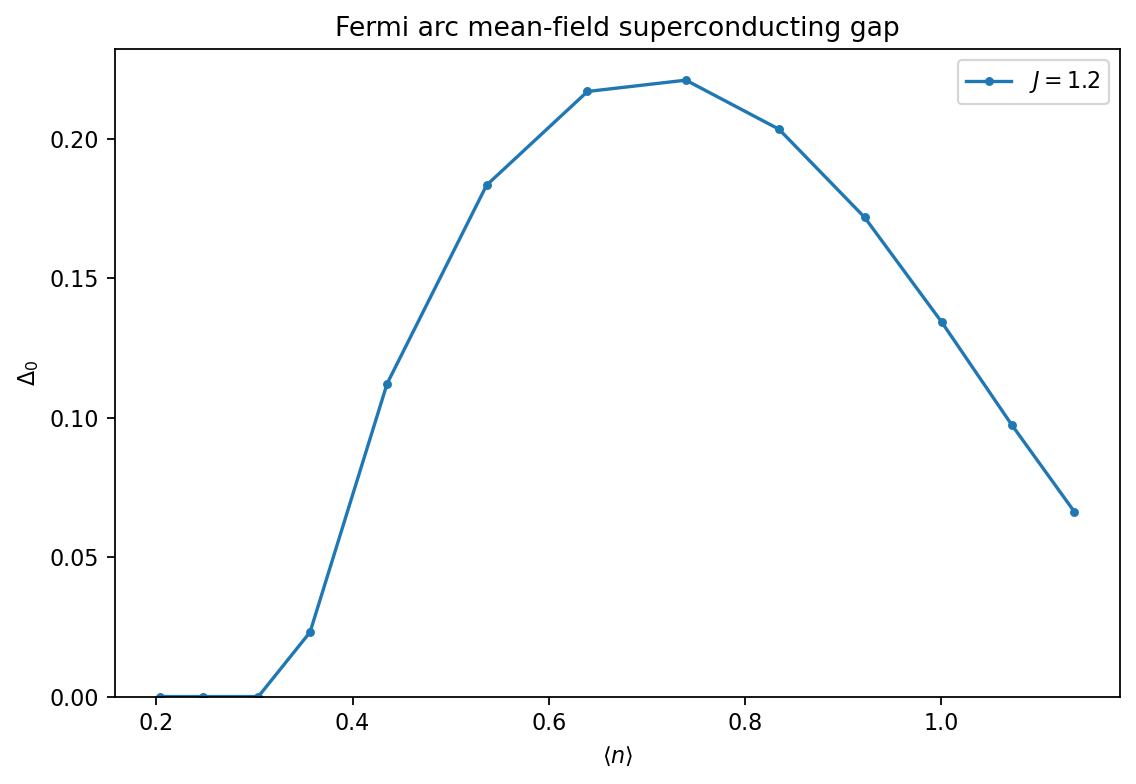

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    xi_k = -2(cos kx + cos ky)
           -4 t1 cos kx cos ky
           -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Block matrices for one Fermi-arc four-mode sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """Diagonalize all blocks and embed eigenvectors into the full 16D basis."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]
    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the Delta_k-channel pair operator ca."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def sector_density(kx, ky, mu, hop, U, Delta0, beta):
    """Average filling contribution of one four-mode sector."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    return 0.5 * np.sum(rho * np.diag(n_eigenbasis)).real


def triangular_kmesh(nk1d):
    """Triangular mesh 0 <= ky <= kx < pi, matching wormsc.tri_kmesh."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """Solve Delta0 = -J <g_k <c_-k down c_k up>> using scipy.root_scalar."""

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta):
    """Compute the triangular-mesh averaged filling for a given Delta0."""
    fillings = []
    for (kx, ky), weight in zip(k_points, k_weights):
        density_k = sector_density(kx, ky, mu, hop, U, Delta0, beta)
        fillings.append(weight * density_k)
    return float(np.sum(fillings) / np.sum(k_weights))


def gap_and_filling_for_mu(k_points, k_weights, J, mu, hop, U, beta):
    """Solve Delta0 at fixed mu and return filling, Delta0."""
    Delta0 = solve_gap_delta0(
        k_points,
        k_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )
    filling = filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta)
    return filling, Delta0


# -------------------------- user parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 0
J_values = [1.2]
# temperature = 1e-04 * J_values[0]
# beta = 1.0 / temperature
beta = 100

# Increase nk_gap and mu_points for smoother curves.
nk_gap = 32
mu_values = np.linspace(-2.5, 0, 13)

k_points, k_weights = triangular_kmesh(nk_gap)

plt.figure(figsize=(7.2, 5.0), dpi=160)

for J in J_values:
    fillings = []
    gaps = []
    curve_start = time.time()

    for mu in mu_values:
        filling, Delta0 = gap_and_filling_for_mu(
            k_points,
            k_weights,
            J=J,
            mu=mu,
            hop=hop,
            U=U,
            beta=beta,
        )
        fillings.append(filling)
        gaps.append(Delta0)
        print(f"J={J:.6g}, mu={mu:.6g}, n={filling:.6g}, Delta0={Delta0:.6g}")

    order = np.argsort(fillings)
    plt.plot(
        np.array(fillings)[order],
        np.array(gaps)[order],
        marker="o",
        markersize=3,
        label=rf"$J={J:.3g}$",
    )
    print(
        f"Finished J={J:.6g}; "
        f"Delta0 range=({np.min(gaps):.4g}, {np.max(gaps):.4g}) "
        f"in {time.time() - curve_start:.2f} s"
    )

plt.xlabel(r"$\langle n\rangle$")
plt.ylabel(r"$\Delta_0$")
plt.title(r"Fermi arc mean-field superconducting gap")
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()
# plt.savefig("fermi_arc_gap_vs_filling.png", bbox_inches="tight")
# plt.close()

print(time.time() - start_time, "seconds")


In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    xi_k = -2(cos kx + cos ky)
           -4 t1 cos kx cos ky
           -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Block matrices for one Fermi-arc four-mode sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    delta_k = Delta0 * pair_form_factor(kx, ky)
    d = delta_k
    dc = np.conjugate(delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """Diagonalize all blocks and embed eigenvectors into the full 16D basis."""
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]
    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the Delta_k-channel pair operator ca."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()
CD_OPS = [op.conj().T for op in C_OPS]
N_OPS = [CD_OPS[i] @ C_OPS[i] for i in range(4)]
N_TOTAL_OP = sum(N_OPS)


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def sector_density(kx, ky, mu, hop, U, Delta0, beta):
    """Average filling contribution of one four-mode sector."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    n_eigenbasis = vectors.conj().T @ N_TOTAL_OP @ vectors
    return 0.5 * np.sum(rho * np.diag(n_eigenbasis)).real


def triangular_kmesh(nk1d):
    """Triangular mesh 0 <= ky <= kx < pi, matching wormsc.tri_kmesh."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """Solve Delta0 = -J <g_k <c_-k down c_k up>> using scipy.root_scalar."""

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return float(np.real(-J * np.sum(vals) / np.sum(k_weights)))

    def residual(delta0):
        return new_delta(delta0) - delta0

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta):
    """Compute the triangular-mesh averaged filling for a given Delta0."""
    fillings = []
    for (kx, ky), weight in zip(k_points, k_weights):
        density_k = sector_density(kx, ky, mu, hop, U, Delta0, beta)
        fillings.append(weight * density_k)
    return float(np.sum(fillings) / np.sum(k_weights))


def gap_and_filling_for_mu(k_points, k_weights, J, mu, hop, U, beta):
    """Solve Delta0 at fixed mu and return filling, Delta0."""
    Delta0 = solve_gap_delta0(
        k_points,
        k_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, max(abs(J), 1e-4)),
    )
    filling = filling_for_delta0(k_points, k_weights, mu, hop, U, Delta0, beta)
    return filling, Delta0


# -------------------------- user parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 0
J_values = [1.2]
# temperature = 1e-04 * J_values[0]
# beta = 1.0 / temperature
beta = 100

# Increase nk_gap and mu_points for smoother curves.
nk_gap = 32
mu_values = np.linspace(-2.5, 0, 13)

k_points, k_weights = triangular_kmesh(nk_gap)

plt.figure(figsize=(7.2, 5.0), dpi=160)

for J in J_values:
    fillings = []
    gaps = []
    curve_start = time.time()

    for mu in mu_values:
        filling, Delta0 = gap_and_filling_for_mu(
            k_points,
            k_weights,
            J=J,
            mu=mu,
            hop=hop,
            U=U,
            beta=beta,
        )
        fillings.append(filling)
        gaps.append(Delta0)
        print(f"J={J:.6g}, mu={mu:.6g}, n={filling:.6g}, Delta0={Delta0:.6g}")

    order = np.argsort(fillings)
    plt.plot(
        np.array(fillings)[order],
        np.array(gaps)[order],
        marker="o",
        markersize=3,
        label=rf"$J={J:.3g}$",
    )
    print(
        f"Finished J={J:.6g}; "
        f"Delta0 range=({np.min(gaps):.4g}, {np.max(gaps):.4g}) "
        f"in {time.time() - curve_start:.2f} s"
    )

plt.xlabel(r"$\langle n\rangle$")
plt.ylabel(r"$\Delta_0$")
plt.title(r"Fermi arc mean-field superconducting gap")
plt.ylim(bottom=0.0)
plt.legend()
plt.tight_layout()
# plt.savefig("fermi_arc_gap_vs_filling.png", bbox_inches="tight")
# plt.close()

print(time.time() - start_time, "seconds")
